# HW 6 CNN's
## Image Classification on Fashion MNIST
### Dirks Wright

In [11]:
### load packages
import os
import random
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import optuna
from optuna.samplers import TPESampler

### set random seeds for reproducibility
RANDOM_STATE = 222

def reset_random_seeds(seed=RANDOM_STATE):
    np.random.seed(seed)
    random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


reset_random_seeds()
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 4)


### Loading & Preprocessing

In [12]:
### load data
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [13]:
(X_train.shape, y_train.shape)

((60000, 28, 28), (60000,))

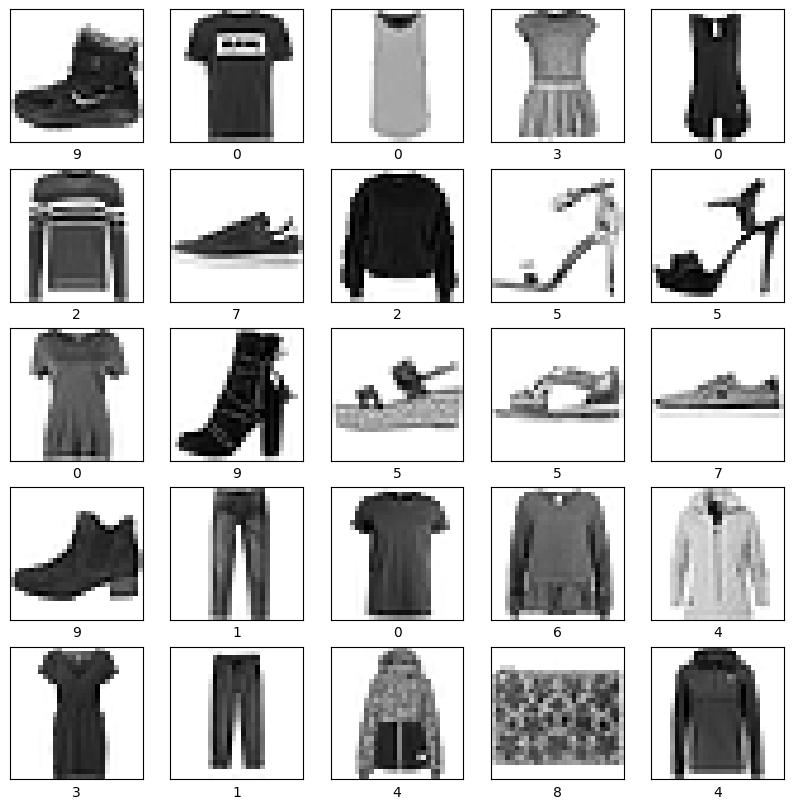

In [14]:
### visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [15]:
from tensorflow.keras import layers, models

In [16]:
### scale data
X_train_norm = X_train / 255.0   
X_test_norm = X_test / 255.0


### flatten images
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1) 
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)    

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [17]:
### preprare data for CNN
X_train_cnn = X_train_norm[..., np.newaxis]  
X_test_cnn = X_test_norm[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)

### create train/validation split for modified CNN models
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_cnn,
    y_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Training split shape:", X_train_split.shape)
print("Validation split shape:", X_val_split.shape)

CNN input shape: (60000, 28, 28, 1)
Training split shape: (54000, 28, 28, 1)
Validation split shape: (6000, 28, 28, 1)


### Build Baseline CNN Model

In [18]:
### define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                
    layers.Conv2D(32, (3,3), activation="relu"),  
    layers.MaxPooling2D((2,2)),                   
    layers.Flatten(),                             
    layers.Dense(64, activation="relu"),          
    layers.Dense(10, activation="softmax"),       
])

In [19]:
### compile the model
cnn_model.compile(
    optimizer="adam",                           
    loss="sparse_categorical_crossentropy",     
    metrics=["accuracy"]                         
)

### train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                 
    y_train,                               
    epochs=5,                                     
    validation_split=0.1                        
)

### evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", cnn_acc) 

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8521 - loss: 0.4155 - val_accuracy: 0.8828 - val_loss: 0.3281
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8962 - loss: 0.2878 - val_accuracy: 0.8903 - val_loss: 0.2972
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9120 - loss: 0.2436 - val_accuracy: 0.8947 - val_loss: 0.2908
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9246 - loss: 0.2096 - val_accuracy: 0.9000 - val_loss: 0.2852
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9351 - loss: 0.1819 - val_accuracy: 0.9003 - val_loss: 0.2956
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8955 - loss: 0.3122
CNN Test Accuracy: 0.8955000042915344


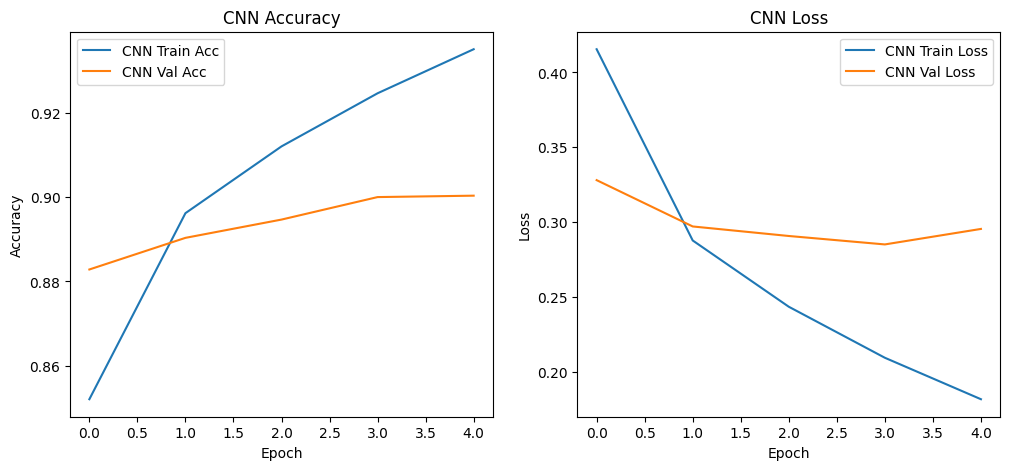

In [20]:
### plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Baseline Model Analysis

The baseline CNN reached a held-out test accuracy of 0.8955. This gives a useful starting point for comparison because it uses a simple architecture with one convolutional layer, one max pooling layer, and one dense hidden layer. The training curve shows the model learned quickly, but by the final epoch the training accuracy was about 0.935 while validation accuracy was about 0.900. That gap suggests overfitting: the model continued improving on the training data while validation performance leveled off.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


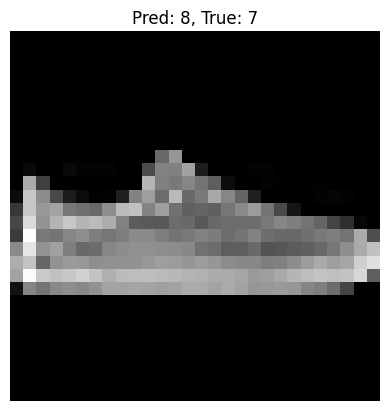

In [21]:
### get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

### find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])

    if pred != y_test[i]:
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### CNN w/ Early Stopping

In [22]:
### add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",            
    patience=5,                    
    restore_best_weights=True      
)

### set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)

### define the CNN model
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),              

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                 
    layers.MaxPooling2D((2, 2)), 

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),              
    layers.MaxPooling2D((2, 2)),         

    layers.Flatten(),                       
    layers.Dense(64, activation="relu"),       
    layers.Dense(10, activation="softmax")     
])

### compile CNN model
cnn_model.compile(
    optimizer="adam",                  
    loss="sparse_categorical_crossentropy",        
    metrics=["accuracy"]                  
)

### train CNN model
cnn_history = cnn_model.fit(
    X_train_split,                            
    y_train_split,                           
    validation_data=(X_val_split, y_val_split), 
    epochs=20,                                
    callbacks=[early_stopping]                
)

### evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8482 - loss: 0.4275 - val_accuracy: 0.8860 - val_loss: 0.3126
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8981 - loss: 0.2806 - val_accuracy: 0.9040 - val_loss: 0.2632
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9131 - loss: 0.2354 - val_accuracy: 0.9130 - val_loss: 0.2443
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9256 - loss: 0.2021 - val_accuracy: 0.9147 - val_loss: 0.2417
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9355 - loss: 0.1735 - val_accuracy: 0.9167 - val_loss: 0.2464
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9463 - loss: 0.1479 - val_accuracy: 0.9205 - val_loss: 0.2495
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9556 - loss: 0.1246 - val_accuracy: 0.9172 - val_loss: 0.2739
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9627 - loss: 0

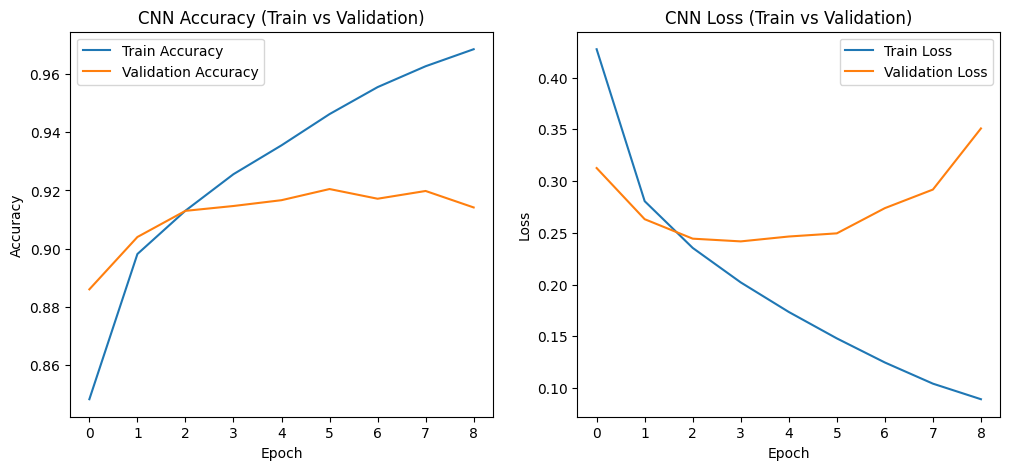

In [23]:
### visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

### plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Early Stopping Analysis

Adding a deeper second convolutional layer and early stopping improved the held-out test accuracy to 0.9127. This was a meaningful gain over the baseline model. The training behavior showed that after the middle epochs, training accuracy continued increasing strongly while validation loss stopped improving and began to rise. By the last displayed epoch, training accuracy was much higher than validation accuracy, which is a clear sign of overfitting. Early stopping helped by restoring the best weights before the model moved too far toward memorizing the training set.

### Data Augmentation on CNN

In [24]:
### set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)

### define data augmentation
### rotate and flip images randomly
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomFlip("horizontal")
])

### define CNN model with data augmentation
cnn_aug_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    ### apply data augmentation during training only
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

### compile augmented CNN model
cnn_aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### train augmented CNN model
cnn_aug_history = cnn_aug_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=20,
)

### evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_model.evaluate(X_test_cnn, y_test)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8017 - loss: 0.5421 - val_accuracy: 0.8548 - val_loss: 0.4000
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8624 - loss: 0.3799 - val_accuracy: 0.8715 - val_loss: 0.3701
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8793 - loss: 0.3319 - val_accuracy: 0.8780 - val_loss: 0.3329
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8890 - loss: 0.3034 - val_accuracy: 0.8945 - val_loss: 0.2949
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8967 - loss: 0.2793 - val_accuracy: 0.9013 - val_loss: 0.2809
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9034 - loss: 0.2640 - val_accuracy: 0.9008 - val_loss: 0.2722
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9060 - loss: 0.2515 - val_accuracy: 0.9040 - val_loss: 0.2655
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9108 - loss: 0

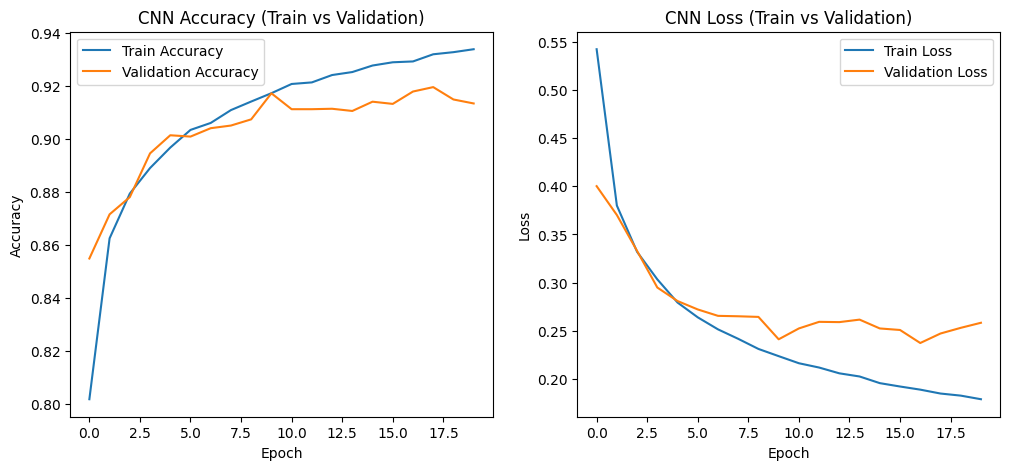

In [25]:
### visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

### plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Data Augmentation Analysis

The data augmentation model reached a test accuracy of 0.9124, which was almost the same as the early stopping model. Random rotation and horizontal flipping made the model train more slowly at first because each batch contained slightly altered images. This acted like regularization: the final training accuracy was lower than the early stopping model, and the training-validation gap was smaller. The tradeoff was that augmentation did not clearly improve the final held-out test accuracy in this run. For this dataset, some transformations may help, but aggressive or less natural transformations can make the learning problem harder without adding useful information.

### 3rd Modified Model: Dropout + Batch Normalization

In [26]:
### set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)

### define CNN model with dropout and batch normalization
cnn_reg_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

### compile regularized CNN model
cnn_reg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### train regularized CNN model
cnn_reg_history = cnn_reg_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=20,
)

### evaluate regularized CNN on test set
cnn_reg_test_loss, cnn_reg_test_acc = cnn_reg_model.evaluate(X_test_cnn, y_test)

print(f"Regularized CNN test accuracy: {cnn_reg_test_acc:.4f}")


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.6114 - loss: 1.0026 - val_accuracy: 0.8218 - val_loss: 0.4986
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.7066 - loss: 0.7452 - val_accuracy: 0.8525 - val_loss: 0.4152
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.7263 - loss: 0.6919 - val_accuracy: 0.8688 - val_loss: 0.3956
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7446 - loss: 0.6571 - val_accuracy: 0.8755 - val_loss: 0.3569
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7609 - loss: 0.6149 - val_accuracy: 0.8767 - val_loss: 0.3523
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.7879 - loss: 0.5523 - val_accuracy: 0.8855 - val_loss: 0.3224
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.8084 - loss: 0.5081 - val_accuracy: 0.8887 - val_loss: 0.3099
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.8183 -

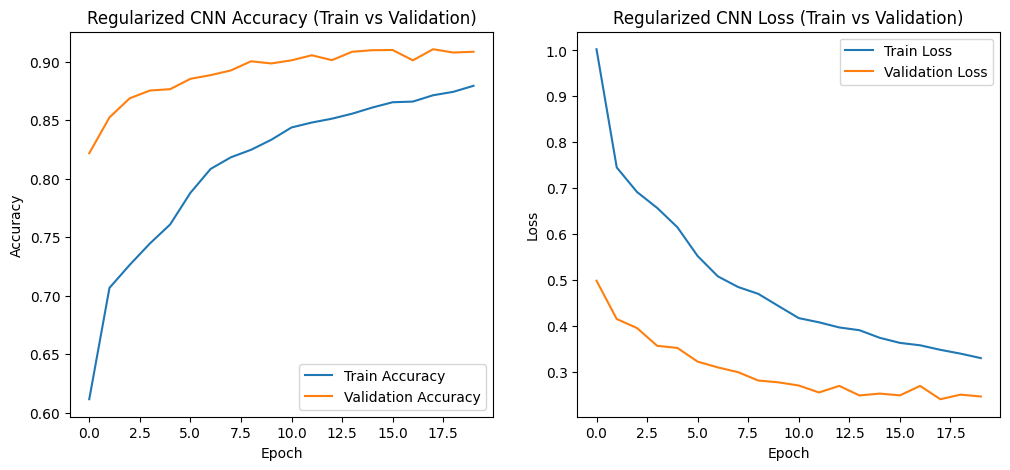

In [27]:
### visualizing train vs validation accuracy for regularized CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_reg_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_reg_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularized CNN Accuracy (Train vs Validation)")
plt.legend()

### plot train vs validation loss for regularized CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_reg_history.history["loss"], label="Train Loss")
plt.plot(cnn_reg_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularized CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Dropout and Batch Normalization Analysis

The dropout and batch normalization model reached a test accuracy of 0.9069. This model reduced overfitting, but the regularization appears to have been too strong for this setup. The training accuracy stayed much lower than the validation accuracy for much of training. The tradeoff is that the model became more resistant to memorization, but it also learned more slowly and did not outperform the simpler early stopping or augmentation models. This suggests that dropout rate and model capacity need to be tuned together rather than added at fixed values.

### Systematic Tuning with Optuna

In [28]:
### smaller training sample for faster tuning
TUNING_SAMPLE_SIZE = 12000
N_TRIALS = 8
TUNING_EPOCHS = 10

X_train_tune, _, y_train_tune, _ = train_test_split(
    X_train_split,
    y_train_split,
    train_size=TUNING_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_split
)

def build_tuned_cnn(params):
    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    for filters in [params["filters_1"], params["filters_2"]]:
        model.add(layers.Conv2D(filters, (3, 3), padding="same"))
        if params["use_batch_norm"]:
            model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(params["dropout_conv"]))

    model.add(layers.Flatten())
    model.add(layers.Dense(
        params["dense_units"],
        activation="relu",
        kernel_regularizer=regularizers.l2(params["l2"])
    ))
    model.add(layers.Dropout(params["dropout_dense"]))
    model.add(layers.Dense(10, activation="softmax"))

    return model

def objective(trial):
    params = {
        "filters_1": trial.suggest_categorical("filters_1", [16, 32, 64]),
        "filters_2": trial.suggest_categorical("filters_2", [32, 64, 128]),
        "dense_units": trial.suggest_categorical("dense_units", [64, 128, 256]),
        "dropout_conv": trial.suggest_float("dropout_conv", 0.1, 0.35),
        "dropout_dense": trial.suggest_float("dropout_dense", 0.2, 0.6),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "l2": trial.suggest_float("l2", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128]),
        "use_batch_norm": trial.suggest_categorical("use_batch_norm", [True, False]),
    }

    tf.keras.backend.clear_session()
    reset_random_seeds()

    model = build_tuned_cnn(params)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    trial_early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True
    )

    model.fit(
        X_train_tune,
        y_train_tune,
        validation_data=(X_val_split, y_val_split),
        epochs=TUNING_EPOCHS,
        batch_size=params["batch_size"],
        callbacks=[trial_early_stopping],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val_split, y_val_split, verbose=0)
    return val_acc

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_TRIALS)

print(f"Best validation accuracy: {study.best_value:.4f}")
print("Best parameters:")
study.best_params


Best validation accuracy: 0.8830
Best parameters:


{'filters_1': 16,
 'filters_2': 128,
 'dense_units': 256,
 'dropout_conv': 0.19380733688223745,
 'dropout_dense': 0.3917606875537225,
 'learning_rate': 0.0003054601665755114,
 'l2': 0.00010201333385401929,
 'batch_size': 64,
 'use_batch_norm': True}

### Optuna Tuning Analysis


### Final Tuned Model Evaluation

In [29]:
### rebuild and train the final model using the best Optuna settings
best_params = study.best_params

tf.keras.backend.clear_session()
reset_random_seeds()

final_model = build_tuned_cnn(best_params)
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    mode="max",
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=20,
    batch_size=best_params["batch_size"],
    callbacks=[final_early_stopping]
)

final_test_loss, final_test_acc = final_model.evaluate(X_test_cnn, y_test, verbose=0)
final_probs = final_model.predict(X_test_cnn, verbose=0)
final_preds = np.argmax(final_probs, axis=1)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, final_preds),
        balanced_accuracy_score(y_test, final_preds),
        precision_score(y_test, final_preds, average="weighted", zero_division=0),
        recall_score(y_test, final_preds, average="weighted", zero_division=0),
        f1_score(y_test, final_preds, average="weighted", zero_division=0),
    ]
})

display(final_metrics)

model_results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Early Stopping CNN",
        "Augmented CNN",
        "Dropout + Batch Norm CNN",
        "Optuna Tuned CNN"
    ],
    "Test Accuracy": [
        cnn_acc,
        cnn_test_acc,
        cnn_aug_test_acc,
        cnn_reg_test_acc,
        final_test_acc
    ]
})

display(model_results.sort_values("Test Accuracy", ascending=False))

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.7829 - loss: 0.6590 - val_accuracy: 0.8642 - val_loss: 0.4170
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.8460 - loss: 0.4688 - val_accuracy: 0.8848 - val_loss: 0.3585
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8642 - loss: 0.4182 - val_accuracy: 0.8897 - val_loss: 0.3386
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.8728 - loss: 0.3862 - val_accuracy: 0.8988 - val_loss: 0.3087
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.8809 - loss: 0.3602 - val_accuracy: 0.9015 - val_loss: 0.3037
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8876 - loss: 0.3446 - val_accuracy: 0.9050 - val_loss: 0.3000
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.8907 - loss: 0.3304 - val_accuracy: 0.9072 - val_loss: 0.2871
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.8963 - loss: 0.3160 - 

,Metric,Score
0,Accuracy,0.9169
1,Balanced Accuracy,0.9169
2,Precision,0.9167
3,Recall,0.9169
4,F1 Score,0.9163


,Model,Test Accuracy
4,Optuna Tuned CNN,0.9169
1,Early Stopping CNN,0.9127
2,Augmented CNN,0.9124
3,Dropout + Batch Norm CNN,0.9069
0,Baseline CNN,0.8955


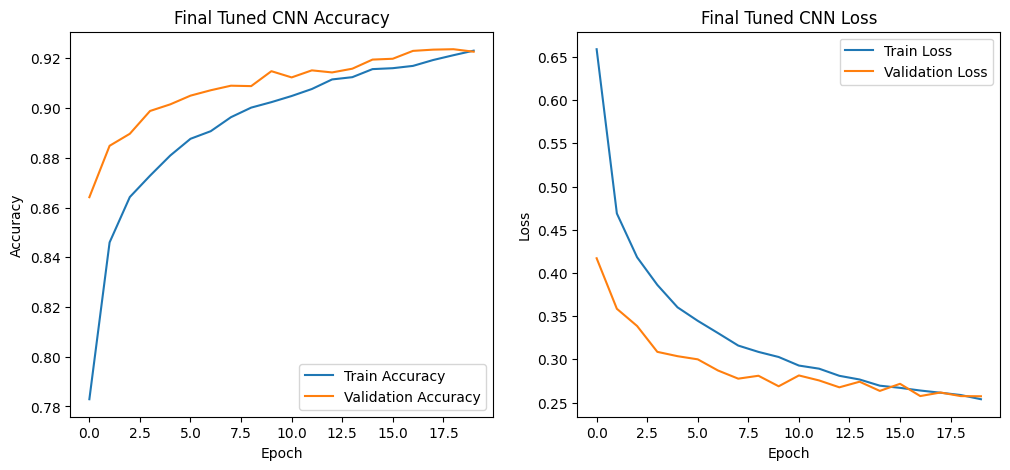

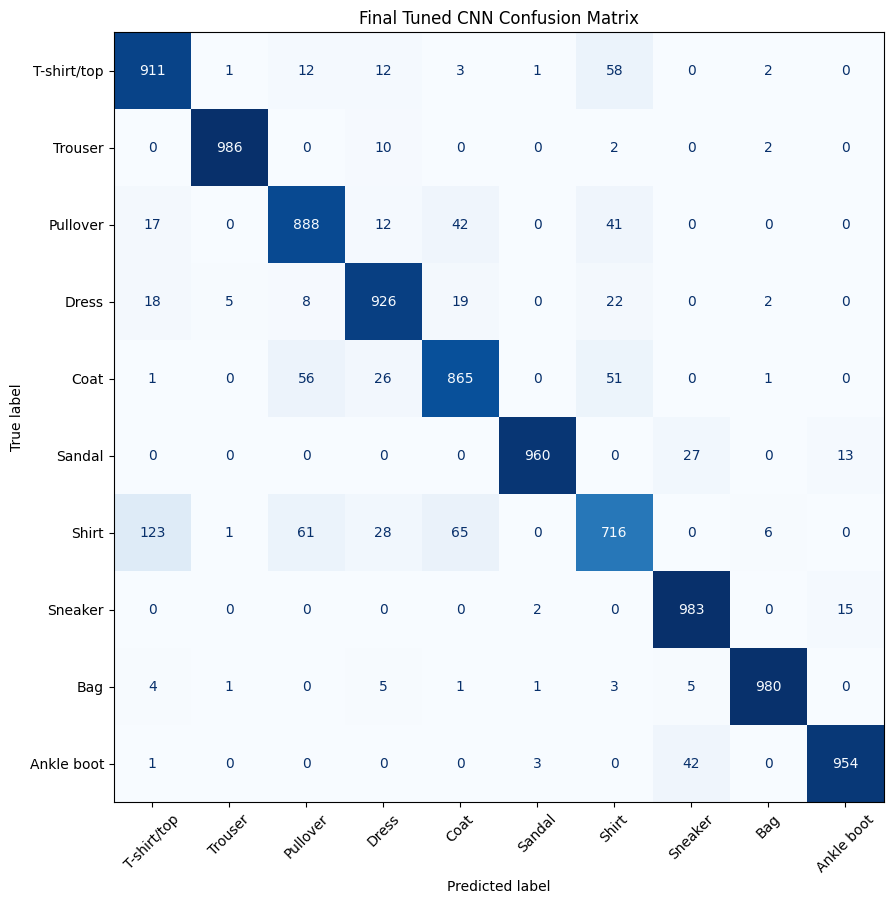

In [30]:
### plot final tuned model training behavior
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.plot(final_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned CNN Loss")
plt.legend()

plt.show()

### confusion matrix for final tuned model
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Final Tuned CNN Confusion Matrix")
plt.show()

### Final Model Conclusions

The final Optuna-tuned CNN was the best-performing model on the held-out test set. It achieved 0.9169 accuracy, and 0.9169 balanced accuracy. Compared with the baseline CNN test accuracy of 0.8955, the final model improved performance by about 2.1 percentage points. It also performed slightly better than the early stopping model at 0.9127, the augmented model at 0.9124, and the dropout plus batch normalization model at 0.9069.

The training and validation curves support the final model choice. The final tuned model ended with training accuracy around 0.923 and validation accuracy around 0.923, so the train-validation gap was small. This suggests the final model generalized better than the early stopping model, where training accuracy rose much higher than validation accuracy after the best validation point. The biggest overfitting appeared in the early stopping experiment, where validation loss began increasing while training accuracy continued to climb. Data augmentation and dropout reduced overfitting, but each came with a tradeoff: augmentation slowed learning and did not improve test accuracy, while fixed dropout and batch normalization made the model more conservative and slightly underfit.

Overall, the changes that helped most were increasing model capacity beyond the baseline, using early stopping to avoid keeping overfit weights, and tuning hyperparameters systematically with Optuna. The final model balanced capacity and regularization better than the hand-built versions.

### Personal Workflow

In the future, I would start CNN projects with a simple baseline model so I have a clear reference point. After that, I would change one factor at a time, such as model depth, data augmentation, dropout, batch normalization, or learning rate, and compare both the test metrics and the training-validation curves. I would watch for overfitting by looking for rising validation loss or a widening train-validation accuracy gap. Once I understand which changes help, I would use a tuning tool like Optuna to search combinations of the most important hyperparameters. My priority would be to choose a model that performs well on the held-out test set without being unnecessarily complex or slow to train.